<div>
  <img style="width:100%" src="https://capsule-render.vercel.app/api?type=waving&height=100&section=header&fontSize=70&fontColor=FFFFFF&color=87CEEB" />
</div>

# **House Prices – Advanced Regression Techniques**


## **Introducción**

* **Problema Seleccionado:**
  El problema seleccionado fue la Predicción del precio de venta de bienes inmuebles a partir de las características de las viviendas, utilizando el conjunto de datos de House Prices - Advanced Regression Techniques.

* **Objetivo del modelo:**
  Desarrollar un modelo orientado a la estimación del precio de venta de bienes inmuebles a partir de un conjunto de variables predictoras de naturaleza numérica y categórica relacionadas con sus condiciones físicas, estructurales, ubicación, calidad e instalaciones de la vivienda.

* **Tipo de problema:**
  Es un problema de aprendizaje supervisado de tipo de regresión, debido a que se busca predecir una variable numérica continua: el precio de venta de una vivienda.

* **Variable objetivo:**
  La variable objetivo es Saleprice, que corresponde al precio de venta de las viviendas.

* **Fuente de los datos:**
  Los datos provienen de Kaggle, específicamente del conjunto de datos seleccionado para House Prices - Advanced Regression Techniques. La información corresponde a viviendas ubicadas en Ames, Lowa, Estados Unidos. El conjunto de entrenamiento utilizado contiene 1.460 observaciones y 81 variables.


El presente proyecto aborda la construcción de un modelo predictivo de aprendizaje automático para estimar el precio de venta de bienes inmuebles. Para ello, se utiliza el conjunto de datos House Prices – Advanced Regression Techniques, seleccionado en la plataforma Kaggle, el cual contiene información sobre diferentes características físicas, estructurales, de calidad y ubicación de las viviendas. A partir de estas variables se busca identificar patrones que permitan predecir la variable objetivo SalePrice.


<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>


## **Descripción del conjunto de datos**

El conjunto de entrenamiento está compuesto por **1.460 observaciones y 81 variables**. Cada observación representa una vivienda diferente, mientras que las variables describen diferentes características relacionadas con sus condiciones físicas, estructurales y de ubicación.


* **Variable Objetivo:**
  La variable objetivo es `SalePrice`, que representa el precio final de venta de cada vivienda. Esta variable es de tipo numérico continuo, por lo que el problema corresponde a un escenario de **aprendizaje supervisado de regresión**. El modelo deberá aprender la relación entre las características de las viviendas y su precio para posteriormente estimar el valor de venta de nuevas propiedades.

* **Variables Predictoras:**
  Las variables predictoras son de diferentes tipos. El conjunto contiene:
  * **Variables numéricas:** Relacionadas, entre otros aspectos, con superficies, años de construcción, cantidad de habitaciones, baños y capacidad del garaje.
  * **Variables categóricas:** Representan características como el tipo de vivienda, el vecindario, la calidad de los materiales, el estado de conservación y diferentes condiciones de la propiedad.
  
  Esta combinación de variables permite analizar el precio de las viviendas desde diferentes perspectivas y requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

* **Tratamiento de Datos Ausentes:**
  Una característica importante del conjunto de datos es la presencia de valores faltantes en algunas variables. Por esta razón, será necesario realizar un análisis previo para determinar la cantidad y proporción de datos ausentes y seleccionar la estrategia de tratamiento más adecuada. Dependiendo de la variable, se podrán considerar técnicas como imputación, eliminación o creación de categorías específicas para representar la ausencia de determinada característica.

* **Limitaciones del Conjunto de Datos:**
  * La información corresponde exclusivamente a viviendas de Ames, Iowa, por lo que los patrones aprendidos por el modelo podrían no generalizarse directamente a otras ciudades o regiones con condiciones económicas, geográficas o inmobiliarias diferentes.
  * El precio de una vivienda puede estar influenciado por factores externos que no se encuentran representados en las variables disponibles, como cambios económicos, condiciones específicas del mercado inmobiliario o características particulares del entorno.
  * La presencia de valores faltantes y de variables categóricas con numerosas categorías puede aumentar la complejidad de la etapa de preprocesamiento.


**Conclusión del Planteamiento**

En consecuencia, el conjunto de datos permite plantear claramente un problema de regresión: a partir de las características conocidas de una vivienda, se busca construir un modelo capaz de estimar su precio de venta (`SalePrice`) con el menor error posible.

<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>

## **Exploración de los datos**

**Importación de librerías**

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Estas instrucciones importan las principales librerías que se utilizarán durante el análisis exploratorio y la preparación de los datos. De manera específica, `pandas` permite cargar, manipular y analizar el conjunto de datos mediante estructuras como los DataFrames. `numpy` proporciona herramientas para realizar operaciones numéricas y matemáticas. `matplotlib.pyplot` permite generar gráficos y visualizaciones, mientras que `seaborn` facilita la creación de gráficos estadísticos para analizar la distribución y las relaciones entre las variables.

**Dimensiones del conjunto de datos**

In [58]:
df = pd.read_csv('train.csv')
print("Dimensiones:", df.shape)
filas, columnas = df.shape
print("Número de observaciones:", filas)
print("Número de variables:", columnas)
df.head()


Dimensiones: (1460, 81)
Número de observaciones: 1460
Número de variables: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Este código carga el archivo `train.csv` mediante la función `read_csv()` de `pandas` y almacena la información en el DataFrame `df`. Posteriormente, `df.shape` permite conocer las dimensiones del conjunto de datos, donde el primer valor corresponde al número de filas u observaciones y el segundo al número de columnas o variables. Las instrucciones `filas, columnas = df.shape` almacenan estos valores por separado para facilitar su interpretación y posterior utilización. Finalmente, `df.head()` muestra las primeras cinco observaciones del conjunto de datos, permitiendo realizar una revisión inicial de su estructura, los nombres de las variables y algunos de los valores registrados.
Para el conjunto House Prices – Advanced Regression Techniques, se tienen **1460 observaciones** y **81 variables**.

Por lo tanto, esta primera exploración permite comprobar que el conjunto de datos utilizado corresponde al dataset seleccionado y que cumple con el requisito de tener al menos 1.000 observaciones.

**Tipos de variables**

In [59]:
df.dtypes.value_counts()

,count
object,43
int64,35
float64,3


Esta línea de código permite identificar los tipos de datos presentes en las variables del conjunto de datos y contabilizar cuántas columnas pertenecen a cada tipo. En este caso, se diferencia principalmente entre variables numéricas (`int64` y  `float64`) y variables categóricas (`object`). Este análisis es importante porque el tipo de variable determina posteriormente qué técnicas de transformación y preparación podrán aplicarse.

Mediante la interpretación, se concluye que, el conjunto de datos está compuesto por 81 variables, de las cuales 43 son de tipo texto (`str`) y corresponden principalmente a variables categóricas, mientras que las 38 restantes son variables numéricas, distribuidas en 35 variables de tipo entero (`int64`) y 3 de tipo decimal (`float64`).

**Identificación y cuantificación de valores faltantes**

              valores_faltantes  porcentaje
PoolQC                     1453       99.52
MiscFeature                1406       96.30
Alley                      1369       93.77
Fence                      1179       80.75
FireplaceQu                 690       47.26
LotFrontage                 259       17.74
GarageCond                   81        5.55
GarageType                   81        5.55
GarageYrBlt                  81        5.55
GarageFinish                 81        5.55
GarageQual                   81        5.55
BsmtFinType2                 38        2.60
BsmtExposure                 38        2.60
BsmtCond                     37        2.53
BsmtQual                     37        2.53
BsmtFinType1                 37        2.53
MasVnrType                    8        0.55
MasVnrArea                    8        0.55
Electrical                    1        0.07


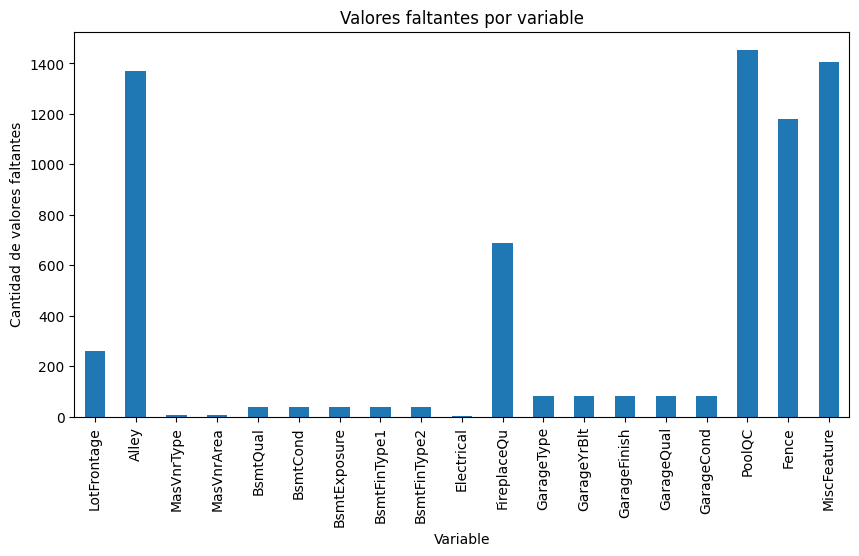

In [60]:
df = pd.read_csv('train.csv', keep_default_na=False, na_values=['NA'])
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100
tabla_nulos = pd.DataFrame({'valores_faltantes': nulos, 'porcentaje': porcentaje.round(2)})
tabla_nulos = tabla_nulos[tabla_nulos['valores_faltantes'] > 0].sort_values('porcentaje', ascending=False)
tabla_nulos
print (tabla_nulos)
plt.figure(figsize=(10, 5))
nulos[nulos > 0].plot(kind="bar")
plt.title("Valores faltantes por variable")
plt.xlabel("Variable")
plt.ylabel("Cantidad de valores faltantes")
plt.show()

Ahora, se identifican las variables que contienen valores faltantes y se calcula tanto la cantidad de datos ausentes como su porcentaje respecto al total de observaciones. Además, se elimina de la tabla las variables que no presentan valores faltantes y se ordenan las restantes de mayor a menor porcentaje. Este procedimiento permite conocer la magnitud del problema y determinar posteriormente qué estrategia de tratamiento resulta adecuada.
En este dataset se pueden observar valores faltantes en variables como `PoolQC`, `Alley`, `LotFrontage`, `FireplaceQu`, entre otras.

Por otra parte, se visualiza de manera gráfica la información anterior. Esta opción, facilita la identificación de las variables con mayor concentración de valores faltantes.

El análisis de valores faltantes permitió identificar 19 variables con al menos un valor ausente dentro del conjunto de datos. La cantidad de valores faltantes varía considerablemente entre las variables, desde un solo registro en `Electrical` (0,07 %) hasta 1.453 registros en `PoolQC` (99,52 %).

Las variables con mayor concentración de valores faltantes son **PoolQC (99,52 %)**, **MiscFeature (96,30 %)**, **Alley (93,77 %)** y **Fence (80,75 %)**. También se observa una cantidad considerable de valores ausentes en **FireplaceQu (47,26 %)** y **LotFrontage (17,74 %)**. Por otro lado, las variables relacionadas con garajes presentan un **5,55 %** de valores faltantes, mientras que las variables asociadas al sótano presentan porcentajes cercanos al **2,5 %**.

De acuerdo con información complementaria de `Kaggle` sobre el conjunto de datos, en varias de estas variables la categoría `NA` representa explícitamente la ausencia de la característica, y no necesariamente un dato que haya sido omitido. Por ejemplo, `PoolQC` utiliza `NA` para indicar que no existe piscina, `Fence` para indicar que no existe cerca, `GarageType` y otras variables del garaje para indicar que no existe garaje, mientras que las variables del sótano utilizan NA para indicar que la vivienda no posee sótano.
Por lo tanto, los valores ausentes deben interpretarse de acuerdo con el significado específico de cada variable. En variables que describen características opcionales de las viviendas, la ausencia puede constituir información válida sobre la propiedad. En cambio, variables como `LotFrontage`, que representa la longitud del frente del lote conectado a la calle, requieren un tratamiento diferente, ya que el diccionario de datos no establece que un valor ausente represente la inexistencia de dicha característica.

En consecuencia, el análisis evidencia que no es adecuado aplicar una única estrategia de tratamiento a todos los valores faltantes. Será necesario diferenciar entre los valores que representan la ausencia de una característica y aquellos que corresponden a información realmente no registrada. Esta distinción será considerada posteriormente en la etapa de preparación de los datos.


**Estadísticas descriptivas**

In [61]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Luego, se generan las estadísticas descriptivas de las variables numéricas del conjunto de datos. Entre los valores obtenidos se encuentran el número de observaciones, media, desviación estándar, valor mínimo, cuartiles y valor máximo. Estas medidas permiten conocer la distribución y escala de las variables, así como detectar posibles valores extremos que posteriormente podrían requerir un análisis adicional.

La mayoría de las variables presentan 1.460 observaciones, correspondientes al total de viviendas, aunque algunas presentan una cantidad inferior debido a la presencia de valores ausentes, como `LotFrontage`, con **1.201 observaciones**, y `MasVnrArea`, con **1.452**.

Se observan diferencias importantes en los rangos de las variables. Por ejemplo, `LotArea` presenta valores entre **1.300 y 215.245 pies cuadrados**, mientras que `SalePrice` presenta valores entre **34.900 y 755.000**. Esto evidencia una considerable variabilidad en las características y precios de las viviendas analizadas.

En particular, la variable objetivo `SalePrice` presenta una `media` de **180.921,20** y una `mediana` de **163.000**. La media superior a la mediana, junto con la diferencia entre el **tercer cuartil (214.000)** y el **valor máximo (755.000)**, sugiere una distribución con asimetría positiva y la posible presencia de valores extremos en el rango superior. Estos valores no se consideran automáticamente errores, por lo que su comportamiento deberá analizarse posteriormente. En términos del dataset, el resultado indica que la mayoría de los precios de venta se concentra en valores bajos y medios, mientras que un grupo reducido de viviendas presenta precios considerablemente más altos.

También se observa que algunas variables relacionadas con características específicas de las viviendas presentan una **mediana igual a cero**, como `PoolArea`, `WoodDeckSF` y `OpenPorchSF`. Esto puede indicar que una proporción importante de las viviendas no posee dichas características. Es importante aclarar que estos valores cero corresponden a valores registrados y deben diferenciarse de los valores ausentes identificados anteriormente.

En conjunto, las estadísticas descriptivas permiten identificar diferencias importantes en escala, dispersión y distribución entre las variables numéricas. Estos resultados servirán como referencia para los análisis posteriores de la distribución de la variable objetivo, la relación entre los predictores y SalePrice, y la identificación de posibles valores extremos.

**Distribución de la variable objetivo**

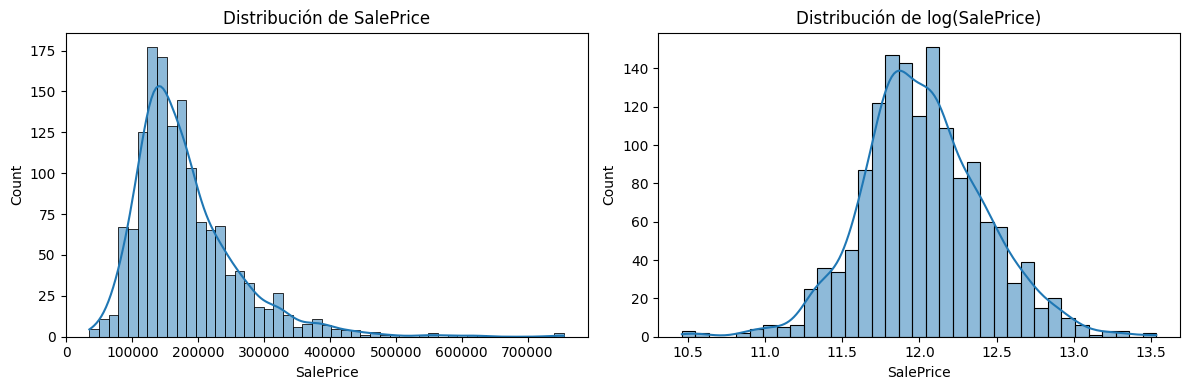

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de SalePrice')
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title('Distribución de log(SalePrice)')
plt.tight_layout()
plt.show()

Este código permite visualizar la distribución de la variable objetivo `SalePrice` mediante dos `histogramas`. El primero muestra los precios de venta en su escala original, mientras que el segundo aplica una transformación logarítmica mediante `log1p()`.

La distribución de `SalePrice` presenta una marcada **asimetría positiva**. La mayoría de los precios de venta se concentra en valores bajos y medios, mientras que un grupo reducido de viviendas presenta precios considerablemente más altos, generando una cola hacia la derecha. Este comportamiento es consistente con las estadísticas descriptivas obtenidas previamente.

Al aplicar una **transformación logarítmica** a `SalePrice`, se observa una distribución más equilibrada y cercana a la simetría. La transformación reduce la influencia de los valores elevados y permite observar una concentración más uniforme de los datos. Este resultado indica que una transformación logarítmica podría ser considerada posteriormente como parte de la preparación de los datos, aunque su aplicación definitiva dependerá del comportamiento y desempeño del modelo.

**Análisis de las relaciones entre las variables predictoras y con la variable objetivo**

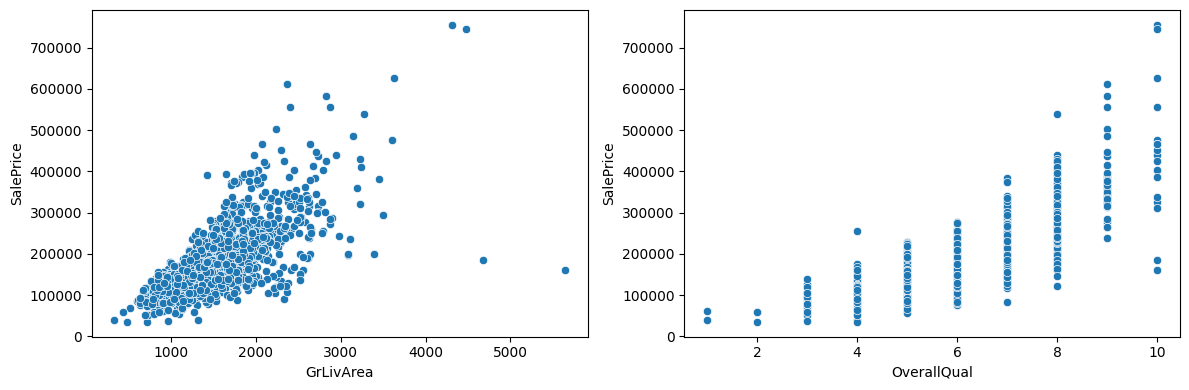

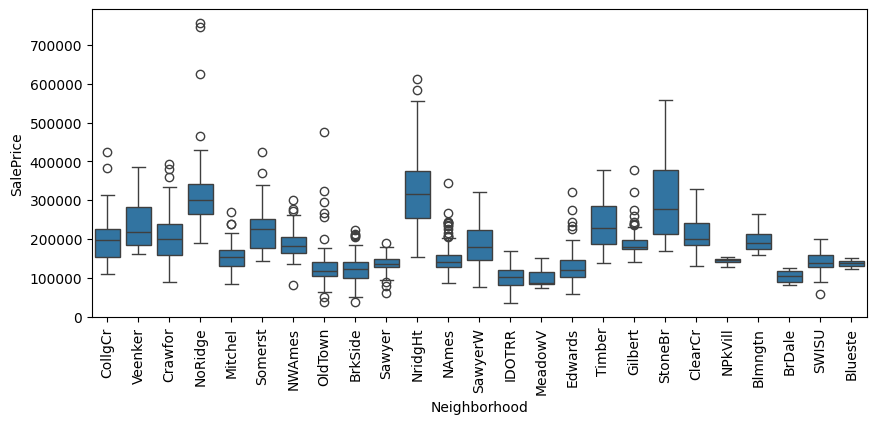

In [63]:
# Numéricas vs SalePrice
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[0])
sns.scatterplot(x='OverallQual', y='SalePrice', data=df, ax=axes[1])
plt.tight_layout()
plt.show()

# Categórica vs SalePrice
plt.figure(figsize=(10, 4))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.show()

Estos gráficos permiten analizar visualmente la relación entre algunas variables predictoras numéricas y la variable objetivo `SalePrice`.

En el primer resultado, se observa una relación positiva entre `GrLivArea`(superficie habitable sobre el nivel del suelo (pies cuadrados)) y `SalePrice`. En términos generales, las viviendas con mayor área habitable tienden a presentar precios de venta más elevados. Sin embargo, la dispersión de los puntos indica que el área habitable por sí sola no explica completamente el precio de las viviendas.

Por otra parte, en la segunda gráfica se puede concluir que existe una relación positiva entre `OverallQual` (calidad general del material y del acabado) y `SalePrice`. A medida que aumenta la calificación general de la vivienda, se observa una tendencia hacia precios de venta más elevados. Esta relación parece ser más marcada que la observada entre `GrLivArea` y `SalePrice`, lo que indica que la calidad general de la vivienda podría ser una variable relevante para explicar las diferencias en el precio.

Por último, el análisis de `Neighborhood` (ubicaciones físicas dentro de los límites de la ciudad de Ames) muestra diferencias en la distribución de `SalePrice` entre los distintos barrios. Se observan variaciones tanto en las medianas como en la dispersión de los precios, lo que indica que la ubicación de la vivienda está asociada con diferencias importantes en su valor de venta. Además, se identifican posibles valores extremos en algunos barrios, los cuales deberán analizarse posteriormente.

Por lo tanto, las relaciones entre los predictores y la variable objetivo evidencian que características como el `área habitable (GrLivArea)`, `la calidad general de la vivienda (OverallQual)` y el `barrio (Neighborhood)` presentan asociaciones con `SalePrice`. Las variables numéricas muestran tendencias positivas, mientras que la variable categórica presenta diferencias en la distribución de precios entre sus categorías. Estos resultados indican que el precio de venta está relacionado con múltiples características de las viviendas, por lo que resulta pertinente considerar diferentes tipos de predictores en el modelo de regresión.

**Análisis de correlación entre variables numéricas.**

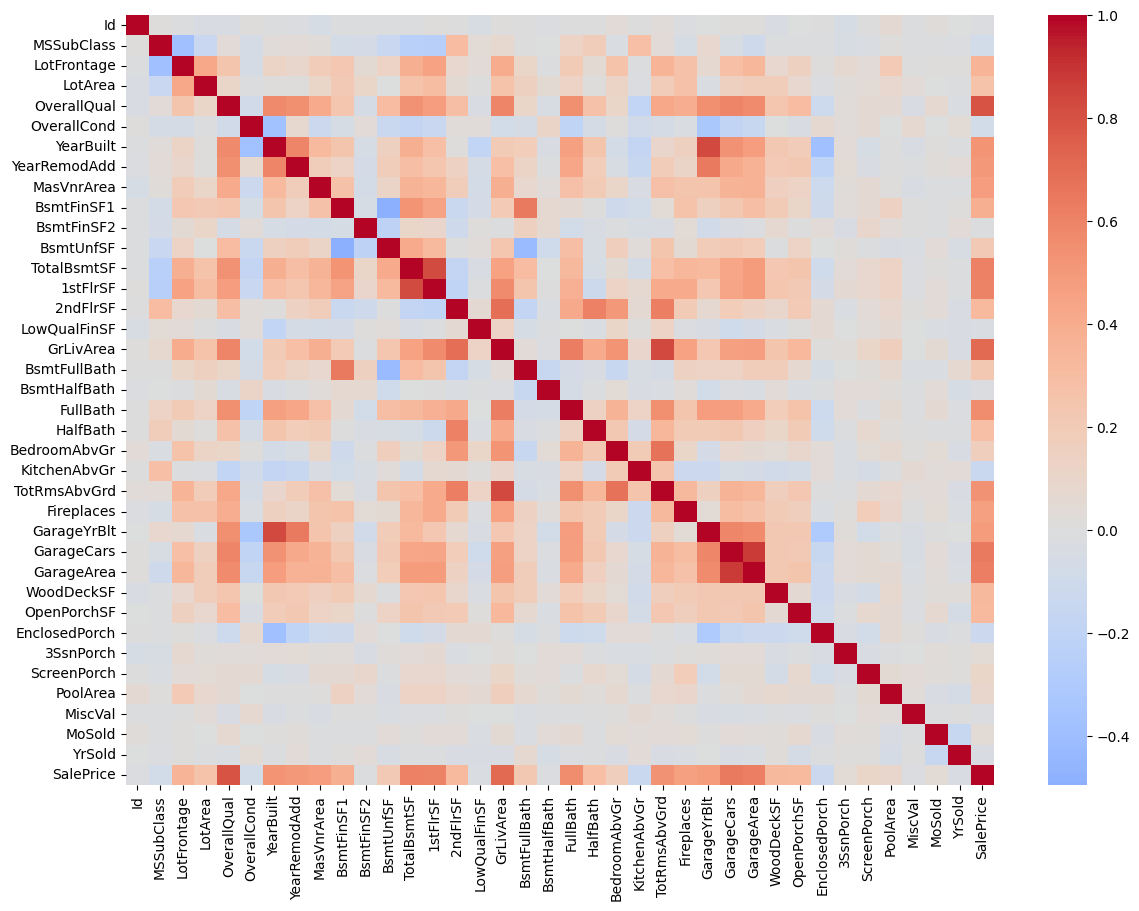

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [64]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()
# Top 10 variables más correlacionadas con SalePrice
corr['SalePrice'].sort_values(ascending=False).head(11)

In [65]:
correlacion = df.select_dtypes(include="number").corr()
correlacion

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


Se realizó un análisis de correlación de las variables numéricas mediante el coeficiente de correlación de Pearson, con el propósito de identificar relaciones lineales entre los predictores y la variable objetivo, con el propósito de identificar relaciones lineales entre los predictores y la variable objetivo `SalePrice`, así como posibles relaciones fuertes entre las propias variables predictoras.

Los resultados muestran que `OverallQual` presenta la mayor correlación positiva con `SalePrice` (0,791), seguida de `GrLivArea` (0,709), `GarageCars` (0,640), `GarageArea` (0,623), `TotalBsmtSFTotalBsmtSF` (0,614) y `1stFlrSF` (0,606). Esto indica que estas variables presentan asociaciones lineales positivas con el precio de venta, es decir, valores mayores de estas características tienden a estar relacionados con precios de venta más elevados.

También se identifican variables con correlaciones cercanas a cero, como `Id` (-0,022), `MiscVal` (-0,021) y `MoSold` (0,046), lo que indica una asociación lineal débil con `SalePrice`.

Adicionalmente, el mapa de correlación permite observar relaciones elevadas entre algunas variables predictoras, como las relacionadas con las características y dimensiones del garaje. Estas relaciones pueden indicar cierta redundancia entre variables y serán consideradas posteriormente durante la preparación y construcción del modelo.

En general, el análisis de correlación permite identificar variables que presentan una asociación lineal importante con la variable objetivo y posibles relaciones entre predictores. Sin embargo, la correlación no implica causalidad ni determina por sí sola qué variables deben incluirse o eliminarse del modelo. Estas decisiones serán evaluadas en las etapas posteriores del proyecto.

**Mapa de valores faltantes**

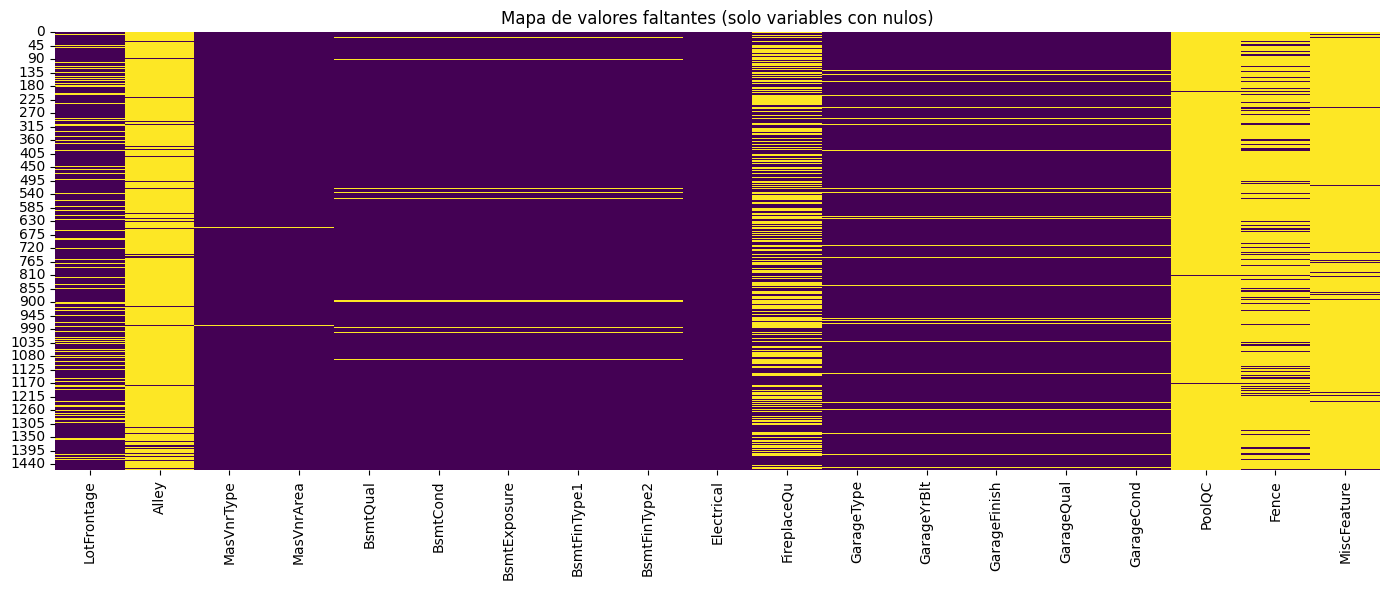

In [66]:
cols_con_nulos = df.columns[df.isnull().any()].tolist()
plt.figure(figsize=(14, 6))
sns.heatmap(df[cols_con_nulos].isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de valores faltantes (solo variables con nulos)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

La visualización de los valores faltantes permite identificar patrones en su distribución entre las viviendas. Se observa que algunas variables presentan una alta concentración de valores faltantes, como `PoolQC`, `MiscFeature`, `Alley`y `Fence`, mientras que otras presentan una cantidad reducida.

Además, se identifican patrones similares entre variables que describen una misma característica de la vivienda, especialmente en los grupos relacionados con el garaje y el sótano, donde los valores faltantes tienden a aparecer en las mismas observaciones. Esto sugiere que, en determinados casos, la ausencia de información puede estar relacionada con la ausencia de la característica correspondiente.

Por otro lado, variables como `LotFrontage` presentan un patrón diferente y requieren un análisis particular. Por esta razón, no resulta adecuado aplicar una única estrategia de tratamiento a todos los valores faltantes; su manejo se definirá posteriormente de acuerdo con el significado y comportamiento de cada variable.

**Cantidad de observaciones por vecindario**

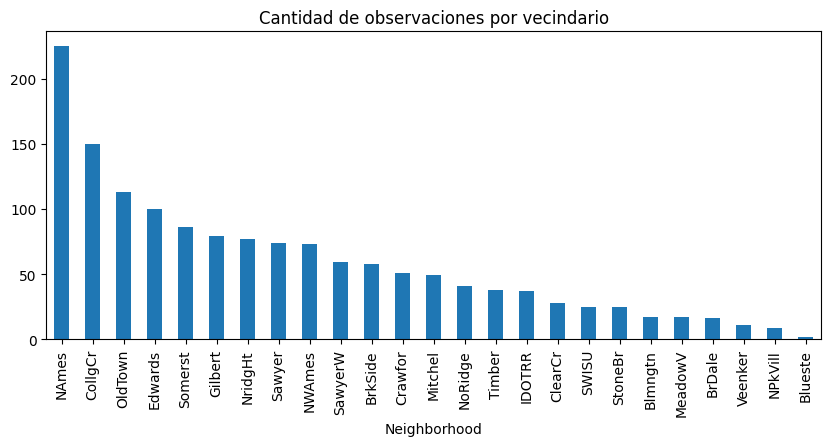

In [67]:
plt.figure(figsize=(10, 4))
df['Neighborhood'].value_counts().plot(kind='bar')
plt.title('Cantidad de observaciones por vecindario')
plt.xticks(rotation=90)
plt.show()

La distribución de observaciones por `Neighborhood` muestra que las categorías de esta variable no presentan la misma cantidad de viviendas. Algunos vecindarios, como `NAmes`, `CollgCr` y `OldTown`, concentran una mayor cantidad de observaciones, mientras que otros, como `BrDale`, `NPkVill` y `Blueste`, presentan una representación considerablemente menor. Esta distribución desigual se tendrá en cuenta al analizar la relación entre el vecindario y `SalePrice`, especialmente en aquellas categorías con un número reducido de observaciones.

<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>

## **Preparacion de los datos**

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv('train.csv', keep_default_na=False, na_values=['NA'])
print(df.shape)

(1460, 81)


In [69]:
df_preparado = df.copy()

print("Dimensiones originales:", df.shape)
print("Dimensiones de la copia:", df_preparado.shape)

Dimensiones originales: (1460, 81)
Dimensiones de la copia: (1460, 81)


Se crea una copia del conjunto de datos original para conservar los datos
iniciales y realizar las transformaciones sobre un nuevo DataFrame.
Esto facilita la reproducibilidad del proceso y permite comparar los datos
antes y después de la preparación.

In [70]:
X = df_preparado.drop(columns=['SalePrice'])
y = df_preparado['SalePrice']

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (1460, 80)
Variable objetivo: (1460,)


Se separa la variable objetivo `SalePrice` de las variables predictoras.

`X` contiene las características de las viviendas que serán utilizadas para
realizar las predicciones, mientras que `y` contiene el precio de venta que
el modelo deberá aprender a estimar.

Esta separación también garantiza que `SalePrice` no sea utilizada
accidentalmente como variable predictora.

In [71]:
X = X.drop(columns=['Id'])

print("Número de variables predictoras después de eliminar Id:", X.shape[1])

Número de variables predictoras después de eliminar Id: 79


La variable `Id` se elimina porque funciona únicamente como un identificador
de cada vivienda y no representa una característica propia del inmueble.

Además, durante el análisis exploratorio se observó que presenta una correlación
muy cercana a cero con `SalePrice`. Por lo tanto, conservarla no aporta
información relevante para explicar el precio de venta y podría introducir
ruido innecesario en el modelo.

In [72]:
cols_none = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
             'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

X[cols_none] = X[cols_none].fillna('None')

No todos los valores faltantes representan errores o datos que no fueron
registrados.

Según el significado de las variables del conjunto House Prices, en algunas
columnas el valor ausente representa que la vivienda no posee determinada
característica. Por ejemplo, un valor ausente en `PoolQC` indica que la
vivienda no posee piscina, mientras que en las variables relacionadas con
el garaje o el sótano indica que la propiedad no dispone de estos espacios.

Por esta razón, en estas variables se creó la categoría `None`, que representa
explícitamente la ausencia de la característica. De esta forma se conserva
información que puede ser relevante para predecir el precio de la vivienda
en lugar de eliminar las observaciones.

In [73]:
# Crear variable que indique si la vivienda posee garaje
X['HasGarage'] = (X['GarageType'] != 'None').astype(int)

# Cuando no existe garaje, GarageYrBlt no tiene un año válido
X['GarageYrBlt'] = X['GarageYrBlt'].fillna(0)

`GarageYrBlt` representa el año de construcción del garaje. En las viviendas
que no poseen garaje este valor no existe, por lo que no resulta apropiado
reemplazarlo directamente por la media o la mediana de los años de construcción.

Se creó la variable `HasGarage`, donde 1 indica que la vivienda posee garaje
y 0 que no lo posee. Posteriormente, los valores ausentes de `GarageYrBlt`
se reemplazaron por 0 para representar la inexistencia del garaje.

Esta transformación conserva el significado original de los datos y evita
asignar artificialmente un año de construcción a una vivienda que no posee
garaje.

In [74]:
X['MasVnrType'] = X['MasVnrType'].fillna('None')
X['MasVnrArea'] = X['MasVnrArea'].fillna(0)

Las variables `MasVnrType` y `MasVnrArea` presentan 8 valores faltantes cada una,
equivalentes aproximadamente al 0,55 % del conjunto de datos.

Se utiliza la categoría `None` en `MasVnrType` para representar la ausencia
de revestimiento de mampostería y se asigna 0 a `MasVnrArea`, indicando que
no existe área asociada a esta característica.

De esta manera se mantienen las observaciones en el conjunto de datos en lugar
de eliminarlas.

In [75]:
nulos_restantes = X.isnull().sum()

nulos_restantes = nulos_restantes[nulos_restantes > 0].sort_values(
    ascending=False
)

print(nulos_restantes)

LotFrontage    259
Electrical       1
dtype: int64


Después de tratar los valores que representan ausencia de características,
se realiza nuevamente una revisión de los datos faltantes.

Los valores que permanecen corresponden a información que no puede interpretarse
directamente como ausencia de una característica. Por ello serán tratados
mediante técnicas de imputación.

In [76]:
variables_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

variables_categoricas = X.select_dtypes(
    include=['object', 'string']
).columns.tolist()

print("Variables numéricas:", len(variables_numericas))
print("Variables categóricas:", len(variables_categoricas))

Variables numéricas: 37
Variables categóricas: 43


Las variables predictoras se dividen entre numéricas y categóricas debido a
que requieren tratamientos diferentes.

Las variables numéricas podrán ser imputadas mediante la mediana y posteriormente
escaladas, mientras que las variables categóricas serán imputadas utilizando
la categoría más frecuente cuando todavía presenten datos faltantes y serán
transformadas mediante codificación One-Hot.

In [77]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [78]:
pipeline_numerico = Pipeline(steps=[
    ('imputacion', SimpleImputer(strategy='median')),
    ('escalamiento', StandardScaler())
])

Para las variables numéricas que todavía contienen información faltante se
utilizará la mediana.

Se eligió la mediana porque es menos sensible a valores extremos que la media.
Esta decisión resulta apropiada considerando que durante el análisis
exploratorio se identificaron variables con distribuciones asimétricas y
posibles valores extremos.

Posteriormente se utiliza `StandardScaler` para colocar las variables numéricas
en escalas comparables. Este procedimiento será especialmente útil para modelos
sensibles a la escala de las variables.

Es importante señalar que tanto la mediana como los parámetros utilizados para
el escalamiento serán calculados exclusivamente con los datos de entrenamiento.

In [79]:
pipeline_categorico = Pipeline(steps=[
    ('imputacion', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

Para las variables categóricas que todavía presenten valores faltantes se
utilizará la categoría más frecuente del conjunto de entrenamiento.

Posteriormente se aplicará codificación One-Hot Encoding. Esta técnica convierte
cada categoría en variables numéricas binarias que pueden ser utilizadas por
los algoritmos de Machine Learning.

Se utiliza `handle_unknown='ignore'` para permitir que, al realizar predicciones
sobre nuevos datos, el modelo pueda recibir categorías que no hayan aparecido
en el conjunto utilizado para ajustar el preprocesamiento sin generar errores.

In [80]:
preprocesador = ColumnTransformer(
    transformers=[
        ('numericas', pipeline_numerico, variables_numericas),
        ('categoricas', pipeline_categorico, variables_categoricas)
    ]
)

preprocesador

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalamiento',
                                                  StandardScaler())]),
                                 ['MSSubClass', 'LotFrontage', 'LotArea',
                                  'OverallQual', 'OverallCond', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea...
                                 ['MSZoning', 'Street', 'Alley', 'LotShape',
                                  'LandContour', 'Utilities', 'LotConfig',
                                  'LandSlope', 'Neighborhood', 'Condition1',
                                  'Condition2', 'BldgType', 'HouseStyle',
                                  'RoofStyle', 'RoofMatl', 'Exterior1st',
                                  'Exterior2nd', 'MasVnrType', 'ExterQual',
                                  'ExterCond', 'Foundation', 'BsmtQual',
                                  'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'Heating', 'HeatingQC',
                                  'CentralAir', 'Electrical', ...])])

Finalmente, se construye un `ColumnTransformer` que permite aplicar de manera
independiente las transformaciones definidas para las variables numéricas y
categóricas.

El preprocesador realizará:

- Imputación mediante mediana en las variables numéricas.
- Estandarización de las variables numéricas.
- Imputación mediante la categoría más frecuente en variables categóricas
  que todavía presenten valores faltantes.
- Codificación One-Hot de las variables categóricas.

En esta etapa únicamente se define el procedimiento. El preprocesador todavía
no se ajusta utilizando `fit`, debido a que primero se realizará la separación
del conjunto de datos en entrenamiento y prueba.

Posteriormente, el preprocesador será ajustado exclusivamente con los datos de
entrenamiento para prevenir fuga de información.

In [81]:
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nCantidad total de valores faltantes después de los tratamientos semánticos:")
print(X.isnull().sum().sum())

print("\nVariables que todavía contienen valores faltantes:")
print(X.columns[X.isnull().any()].tolist())

print("\nCantidad de variables numéricas:", len(variables_numericas))
print("Cantidad de variables categóricas:", len(variables_categoricas))

Dimensiones de X: (1460, 80)
Dimensiones de y: (1460,)

Cantidad total de valores faltantes después de los tratamientos semánticos:
260

Variables que todavía contienen valores faltantes:
['LotFrontage', 'Electrical']

Cantidad de variables numéricas: 37
Cantidad de variables categóricas: 43


#### **Resultado de la preparación**

La preparación realizada conserva las 1.460 viviendas del conjunto de datos,
evitando eliminar observaciones únicamente por presentar valores faltantes.

Los valores ausentes cuyo significado corresponde a la inexistencia de una
característica fueron tratados explícitamente, mientras que los valores
realmente no registrados serán imputados mediante procedimientos incluidos
dentro del pipeline de preprocesamiento.

También se eliminó `Id` por tratarse de un identificador y se definieron
tratamientos independientes para las variables numéricas y categóricas.

No se eliminaron variables únicamente por presentar una correlación elevada.
Aunque durante el análisis exploratorio se observaron relaciones importantes
entre variables asociadas al garaje y otras características de la vivienda,
la correlación por sí sola no constituye un criterio suficiente para descartar
una variable.

El preprocesador no ha sido ajustado todavía. En la siguiente sección se
realizará la separación entre entrenamiento y prueba y posteriormente las
transformaciones se ajustarán exclusivamente sobre los datos de entrenamiento,
evitando así fuga de información.




<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>

## **Separación de entrenamiento y prueba**

Para evaluar el desempeño del modelo de regresión se realizó una separación del conjunto de datos en dos subconjuntos: **80 % para entrenamiento y 20 % para prueba**. El conjunto de datos utilizado contiene **1.460 observaciones** correspondientes a diferentes viviendas, por lo que la división genera aproximadamente **1.168 observaciones para entrenamiento y 292 para prueba**.

La separación se realiza mediante el método `train_test_split` de la librería `scikit-learn`, utilizando una división aleatoria de los datos. La variable objetivo `SalePrice` se mantiene separada de las variables predictoras antes de realizar este procedimiento: `X` contiene las características de las viviendas y `y` contiene los precios de venta.

El procedimiento utilizado es el siguiente:

In [82]:
from sklearn.model_selection import train_test_split

# Separar los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Verificar las dimensiones de cada conjunto
print("Datos de entrenamiento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nDatos de prueba:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Datos de entrenamiento:
X_train: (1168, 80)
y_train: (1168,)

Datos de prueba:
X_test: (292, 80)
y_test: (292,)


El parámetro `test_size=0.20` establece que el **20 % de las observaciones** se destina al conjunto de prueba, mientras que el **80 % restante** se utiliza para entrenar el modelo. El parámetro `random_state=42` permite que la división sea reproducible, de modo que al ejecutar nuevamente el notebook se obtenga la misma distribución de observaciones.

En cuanto al riesgo de fuga de información, el conjunto de datos no presenta **grupos naturales** como pacientes, usuarios o vehículos con múltiples registros relacionados entre sí. Cada observación corresponde a una vivienda diferente, por lo que no es necesario mantener determinados registros agrupados durante la separación. En consecuencia, no se requiere utilizar estrategias específicas de separación por grupos, como `GroupKFold` o `GroupShuffleSplit`.

En este caso, una división aleatoria mediante `train_test_split` resulta adecuada, ya que permite distribuir las viviendas entre los conjuntos de entrenamiento y prueba de forma independiente. Así, el modelo se entrena con un conjunto de viviendas y posteriormente se evalúa con viviendas que no fueron utilizadas durante el entrenamiento, reduciendo el riesgo de fuga de información y permitiendo obtener una evaluación más representativa del desempeño del modelo.


<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>

## **Prevención de fuga de información**

La fuga de información (*data leakage*) ocurre cuando información que no estaría disponible en el momento de realizar una predicción es utilizada durante el entrenamiento del modelo. Para evitar este problema, se revisó el proceso de preparación, transformación y entrenamiento de los datos.

En primer lugar, la variable objetivo `SalePrice` se mantiene separada de las variables predictoras, por lo que el precio de venta no se utiliza como característica de entrada del modelo. De esta manera, el modelo aprende únicamente a partir de las características disponibles de cada vivienda.

Posteriormente, el conjunto de datos se divide en **80 % para entrenamiento y 20 % para prueba** mediante `train_test_split`. El conjunto de prueba se mantiene independiente y no interviene durante el entrenamiento del modelo. Su utilización se realiza únicamente en la etapa de evaluación, permitiendo medir el desempeño del modelo sobre datos que no fueron utilizados durante su aprendizaje.

Para evitar que las transformaciones generen fuga de información, el preprocesamiento se ajusta únicamente utilizando los datos de entrenamiento. En las variables numéricas se realiza la imputación de valores faltantes mediante la mediana y posteriormente el escalamiento. En las variables categóricas se realiza la imputación mediante la categoría más frecuente y la codificación mediante `OneHotEncoder`. Estas transformaciones se ajustan utilizando exclusivamente `X_train` y posteriormente se aplican a `X_test` sin volver a calcular sus parámetros.

De esta manera, las estadísticas utilizadas para la imputación y el escalamiento, así como las categorías aprendidas durante la codificación, no utilizan información proveniente del conjunto de prueba. Esto permite mantener la independencia entre los datos utilizados para entrenar y los datos utilizados para evaluar el modelo.

Finalmente, se revisaron las variables utilizadas como predictoras para evitar incluir información que solo estaría disponible después del evento que se desea predecir. La variable `SalePrice`, al representar el precio de venta que se busca estimar, se mantiene exclusivamente como variable objetivo.

Con estas medidas se busca garantizar que el modelo sea entrenado únicamente con información disponible antes de realizar la predicción y que la evaluación se realice sobre datos independientes, reduciendo así el riesgo de fuga de información y obteniendo una estimación más realista del desempeño del modelo.




<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>

##  **Modelo base**

Antes de desarrollar el modelo predictivo principal, se construye un modelo base (baseline) con el propósito de establecer un punto de referencia para evaluar posteriormente si el modelo desarrollado representa una mejora.

Dado que el objetivo del proyecto es predecir `SalePrice`, se trabaja con un problema de regresión. Para establecer la línea base se utiliza `DummyRegressor` con la estrategia `mean`, que genera predicciones utilizando la media de la variable objetivo aprendida exclusivamente a partir del conjunto de entrenamiento.

Este modelo no utiliza las características de las viviendas para aprender relaciones entre las variables predictoras y el precio de venta. Su finalidad es proporcionar una referencia sencilla contra la cual comparar posteriormente el desempeño del modelo predictivo.

###  **Construcción y entrenamiento del modelo base**

Se utiliza `DummyRegressor` con la estrategia `mean`. El modelo se ajusta utilizando los datos de entrenamiento, por lo que el valor constante utilizado para realizar las predicciones corresponde únicamente a la media de `y_train`.

De esta manera, el conjunto de prueba permanece independiente y se mantiene la estrategia adoptada para prevenir fuga de información.

In [83]:
from sklearn.dummy import DummyRegressor

# Crear el modelo base utilizando la media de la variable objetivo
modelo_base = DummyRegressor(strategy="mean")

# Entrenar el modelo únicamente con los datos de entrenamiento
modelo_base.fit(X_train, y_train)

# Mostrar el valor promedio aprendido por el modelo
print(f"Media de SalePrice aprendida: {modelo_base.constant_[0][0]:,.2f}")

Media de SalePrice aprendida: 181,441.54


###  **Predicciones del modelo base**

Una vez entrenado el modelo base, se generan predicciones sobre el conjunto de prueba. Debido a que se utiliza la estrategia `mean`, todas las observaciones reciben como predicción el mismo valor: la media de `SalePrice` aprendida durante el entrenamiento.

In [84]:
# Generar predicciones sobre el conjunto de prueba
y_pred_base = modelo_base.predict(X_test)

# Mostrar las primeras predicciones
print("Primeras 10 predicciones del modelo base:")
print(y_pred_base[:10])

Primeras 10 predicciones del modelo base:
[181441.54195205 181441.54195205 181441.54195205 181441.54195205
 181441.54195205 181441.54195205 181441.54195205 181441.54195205
 181441.54195205 181441.54195205]


### **Evaluación del modelo base**

Para cuantificar el desempeño del modelo base se calculan las métricas MAE (Error Absoluto Medio), RMSE (Raíz del Error Cuadrático Medio) y R².

- **MAE:** representa el error absoluto promedio entre los precios reales y los precios predichos.
- **RMSE:** mide el error de predicción dando mayor peso a los errores grandes.
- **R²:** permite analizar qué proporción de la variabilidad de la variable objetivo es explicada por el modelo.

Los resultados obtenidos servirán como referencia para comparar posteriormente el desempeño del modelo predictivo.

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcular las métricas del modelo base
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print("Resultados del modelo base:")
print(f"MAE:  {mae_base:,.2f}")
print(f"RMSE: {rmse_base:,.2f}")
print(f"R²:   {r2_base:.4f}")

Resultados del modelo base:
MAE:  62,575.93
RMSE: 87,619.03
R²:   -0.0009


### **Interpretación de resultados**

El modelo base implementado mediante `DummyRegressor` con la estrategia `mean` generó predicciones constantes de aproximadamente $181,441.54, correspondientes al precio promedio de las viviendas del conjunto de entrenamiento.

Al evaluar el modelo sobre el conjunto de prueba, se obtuvo un MAE de $62,575.93, lo que indica que las predicciones presentan un error absoluto promedio de aproximadamente $62,576 respecto a los precios reales. Por otra parte, el RMSE fue de $87,619.03, lo que refleja una mayor penalización de los errores de predicción más elevados.

El coeficiente de determinación R² fue de -0.0009, un valor cercano a cero que evidencia que el modelo base prácticamente no explica la variabilidad de los precios de venta.

Estos resultados son coherentes con el comportamiento esperado de un modelo que utiliza únicamente la media de la variable objetivo. Las métricas obtenidas constituyen un punto de referencia para determinar posteriormente si el modelo predictivo logra reducir los errores y mejorar la capacidad de predicción.

In [86]:
import pandas as pd

resultados_base = pd.DataFrame({
    "Modelo": ["DummyRegressor"],
    "MAE": [mae_base],
    "RMSE": [rmse_base],
    "R2": [r2_base]
})

display(resultados_base)

,Modelo,MAE,RMSE,R2
0,DummyRegressor,62575.926452,87619.034506,-0.000882


<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>

##  **Modelo predictivo**

Después de establecer el desempeño de referencia mediante el modelo base, se construye un modelo predictivo que utiliza las características de las viviendas para estimar la variable objetivo `SalePrice`.

Como primera alternativa se selecciona un modelo de **Regresión Lineal**, debido a que el problema corresponde a una tarea de regresión y la variable objetivo es numérica continua. Este modelo permite establecer una relación entre las variables predictoras y el precio de venta de las viviendas.

El modelo se integrará con el preprocesamiento definido previamente mediante un `Pipeline`. De esta manera, la imputación, el escalamiento y la codificación de las variables categóricas se ajustarán exclusivamente utilizando los datos de entrenamiento, evitando que información del conjunto de prueba intervenga durante el aprendizaje.

## **Entrenamiento del modelo**

Para integrar el preprocesamiento y el algoritmo de regresión se utiliza un `Pipeline` de `scikit-learn`.

El pipeline aplica primero las transformaciones definidas en la etapa de preparación de los datos y posteriormente entrena el modelo de Regresión Lineal. Al ejecutar `fit` utilizando `X_train` y `y_train`, tanto los parámetros del preprocesamiento como los parámetros del modelo se aprenden exclusivamente a partir del conjunto de entrenamiento.

Esta estrategia permite mantener un flujo de entrenamiento reproducible y reduce el riesgo de fuga de información.

In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Construir pipeline completo: preprocesamiento + modelo
modelo_predictivo = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LinearRegression())
])

modelo_predictivo

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalamiento',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF',...
                                                   'LandContour', 'Utilities',
                                                   'LotConfig', 'LandSlope',
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('modelo', LinearRegression())])

In [88]:
# Entrenar el pipeline utilizando únicamente los datos de entrenamiento
modelo_predictivo.fit(X_train, y_train)

print("Modelo predictivo entrenado correctamente.")

Modelo predictivo entrenado correctamente.


#### **Predicciones sobre el conjunto de prueba**

Una vez entrenado el modelo, se generan predicciones sobre `X_test`. El pipeline aplica a estos datos las transformaciones aprendidas previamente durante el entrenamiento y posteriormente utiliza el modelo de Regresión Lineal para estimar `SalePrice`.

El conjunto de prueba no se utiliza para reajustar el preprocesamiento ni el modelo.

In [89]:
# Generar predicciones sobre el conjunto de prueba
y_pred_modelo = modelo_predictivo.predict(X_test)

print("Primeras 10 predicciones:")
print(y_pred_modelo[:10])

Primeras 10 predicciones:
[160141.22104349 342824.88320246  90140.87261952 176422.17406552
 321478.05706719  67963.06785635 239477.93186736 146523.96017955
  62771.12617411 151706.12180479]


In [90]:
# Evaluar el modelo predictivo con las mismas métricas del modelo base
mae_modelo = mean_absolute_error(y_test, y_pred_modelo)
rmse_modelo = np.sqrt(mean_squared_error(y_test, y_pred_modelo))
r2_modelo = r2_score(y_test, y_pred_modelo)

print("Resultados del modelo predictivo:")
print(f"MAE:  {mae_modelo:,.2f}")
print(f"RMSE: {rmse_modelo:,.2f}")
print(f"R²:   {r2_modelo:.4f}")

Resultados del modelo predictivo:
MAE:  21,108.07
RMSE: 65,385.64
R²:   0.4426


In [91]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "DummyRegressor",
        "Regresión Lineal"
    ],
    "MAE": [
        mae_base,
        mae_modelo
    ],
    "RMSE": [
        rmse_base,
        rmse_modelo
    ],
    "R²": [
        r2_base,
        r2_modelo
    ]
})

comparacion_modelos

,Modelo,MAE,RMSE,R²
0,DummyRegressor,62575.926452,87619.034506,-0.000882
1,Regresión Lineal,21108.066262,65385.636790,0.442621


##  **Interpretación de resultados**

El modelo de Regresión Lineal presentó un mejor desempeño que el modelo base. El MAE disminuyó de aproximadamente **$62,575.93** en el `DummyRegressor` a **$21,108.07** en la Regresión Lineal, lo que indica una reducción considerable del error absoluto promedio en la estimación del precio de las viviendas.

El RMSE también disminuyó, pasando de aproximadamente **$87,619.03** a **$65,385.64**. Aunque este resultado evidencia una mejora frente al modelo base, la diferencia entre el MAE y el RMSE sugiere que todavía existen observaciones en las que el modelo presenta errores de predicción elevados.

Por otra parte, el R² pasó de **-0.0009** en el modelo base a **0.4426** en la Regresión Lineal. Esto indica que el modelo predictivo logra explicar aproximadamente el **44.26 % de la variabilidad de `SalePrice`** presente en el conjunto de prueba, representando una mejora frente al modelo de referencia.

En conjunto, los resultados muestran que incorporar las características de las viviendas permite obtener predicciones más cercanas a los valores reales que utilizar únicamente el precio promedio. Sin embargo, las métricas también indican que existe margen de mejora, especialmente en aquellas observaciones donde se presentan errores elevados.

Entre las principales dificultades se encuentra la heterogeneidad del conjunto de datos, debido a la presencia de variables numéricas y categóricas, valores faltantes y diferentes escalas, lo que hizo necesario implementar un proceso de preprocesamiento antes del entrenamiento. El uso de un `Pipeline` permitió integrar estas transformaciones con el modelo y aplicarlas sin utilizar información del conjunto de prueba durante el ajuste.

Como trabajo futuro podrían evaluarse otros algoritmos capaces de representar relaciones más complejas entre las características de las viviendas y su precio, así como analizar posibles valores atípicos y realizar ajustes adicionales en la selección o transformación de variables.

<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>

## **Evaluación del modelo**



La evaluación del modelo permite determinar qué tan bien las predicciones realizadas se aproximan a los valores reales de la variable objetivo. En este proyecto, la variable objetivo es **`SalePrice`**, correspondiente al precio de venta de las viviendas, por lo que el problema trabajado corresponde a un **problema de regresión supervisada**.

Para evaluar el desempeño del modelo predictivo se utilizarán métricas apropiadas para problemas de regresión:

- **MAE (Mean Absolute Error):** mide el error absoluto promedio entre los valores reales y las predicciones.
- **RMSE (Root Mean Squared Error):** mide el error de las predicciones, dando mayor peso a los errores de mayor magnitud.
- **R² (Coeficiente de Determinación):** indica qué proporción de la variabilidad de los precios puede ser explicada por el modelo.

Estas métricas permiten analizar el desempeño desde diferentes perspectivas: el **error promedio de las predicciones**, el **impacto de los errores de mayor magnitud** y la **capacidad explicativa del modelo**.

Además, el desempeño del modelo predictivo se comparará con el **modelo base**, construido previamente mediante `DummyRegressor` con la estrategia de la media. Esta comparación permite determinar si el modelo predictivo aporta una capacidad de predicción adicional frente a una estrategia sencilla que utiliza como estimación el **precio promedio de las viviendas**.




### **Selección y justificación de las métricas**

Debido a que `SalePrice` es una variable numérica continua, se seleccionan métricas de evaluación correspondientes a problemas de **regresión**.


#### *MAE — Mean Absolute Error*

El **MAE** representa el error absoluto promedio entre los valores reales y los valores predichos por el modelo.

Esta métrica permite interpretar directamente cuánto se alejan, en promedio, las predicciones del precio real de las viviendas. Además, el error se expresa en las mismas unidades monetarias de `SalePrice`.

Es adecuada porque permite conocer de forma sencilla el error promedio del modelo y no da un peso tan elevado a los errores grandes como el RMSE.

**Interpretación:** cuanto menor sea el MAE, mejor será el desempeño del modelo.


#### *RMSE — Root Mean Squared Error*

El **RMSE** mide la magnitud promedio de los errores de predicción, dando mayor peso a los errores grandes debido a que estos se elevan al cuadrado antes de calcular el promedio.

Esta característica es relevante para este problema, ya que una predicción que se aleje considerablemente del precio real de una vivienda representa un error importante que debe ser identificado durante la evaluación.

**Interpretación:** cuanto menor sea el RMSE, mejor será el desempeño del modelo.


#### *R² — Coeficiente de Determinación*

El **R²** permite determinar qué proporción de la variabilidad observada en `SalePrice` puede ser explicada por el modelo a partir de las variables predictoras.

Esta métrica complementa al MAE y al RMSE porque, en lugar de medir directamente el tamaño del error, permite analizar la **capacidad explicativa del modelo**.

Un valor de R² más cercano a **1** indica una mayor capacidad para explicar la variabilidad de la variable objetivo, mientras que un valor cercano a **0** indica una capacidad explicativa limitada.

**Interpretación:** cuanto mayor sea el R², mejor será el desempeño del modelo.



#### *Justificación general*

Se utilizan las tres métricas porque proporcionan perspectivas complementarias sobre el desempeño del modelo:

- **MAE:** permite interpretar el error promedio en las mismas unidades del precio.
- **RMSE:** da mayor importancia a los errores de gran magnitud.
- **R²:** permite analizar la capacidad explicativa del modelo.

Por esta razón, no se considera suficiente utilizar una única métrica, ya que el uso conjunto de **MAE, RMSE y R²** permite realizar una evaluación más completa del modelo predictivo.

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [93]:

predicciones_base = modelo_base.predict(X_test)

print("Predicciones del modelo base realizadas correctamente.")

Predicciones del modelo base realizadas correctamente.


Se generan las predicciones sobre el conjunto de prueba utilizando el **modelo base** construido previamente.

El modelo base utiliza una estrategia sencilla basada en la **media de la variable objetivo**. Por lo tanto, sirve como punto de referencia para determinar si el modelo predictivo desarrollado posteriormente logra aprender relaciones útiles entre las características de las viviendas y `SalePrice`.

La evaluación se realiza sobre `X_test`, el conjunto de datos que **no fue utilizado directamente durante el entrenamiento**, permitiendo obtener una evaluación más objetiva del desempeño del modelo.

In [94]:

predicciones_modelo = modelo_predictivo.predict(X_test)

print("Predicciones del modelo predictivo realizadas correctamente.")

Predicciones del modelo predictivo realizadas correctamente.


A continuación, se generan las predicciones del **modelo predictivo** sobre el conjunto de prueba.

El modelo predictivo corresponde a una **Regresión Lineal**, integrada con el proceso de preprocesamiento de las variables. De esta manera, las predicciones se generan utilizando las características de las viviendas presentes en `X_test`.

Estas predicciones serán posteriormente comparadas con los valores reales de `y_test` mediante las **métricas de evaluación seleccionadas**.

In [95]:
# MAE del modelo base
mae_base = mean_absolute_error(y_test, predicciones_base)

# RMSE del modelo base
rmse_base = np.sqrt(mean_squared_error(y_test, predicciones_base))

# R² del modelo base
r2_base = r2_score(y_test, predicciones_base)

print("Resultados del modelo base:")
print(f"MAE:  {mae_base:.2f}")
print(f"RMSE: {rmse_base:.2f}")
print(f"R²:   {r2_base:.4f}")

Resultados del modelo base:
MAE:  62575.93
RMSE: 87619.03
R²:   -0.0009


En esta etapa se calculan las tres métricas seleccionadas para el **modelo base**: **MAE, RMSE y R²**.

Estos valores servirán como referencia para determinar si el modelo predictivo basado en **Regresión Lineal** logra mejorar el desempeño obtenido mediante la estrategia base.

No se establece todavía una conclusión sobre el desempeño, ya que esta se realizará posteriormente al **comparar los resultados de ambos modelos utilizando las mismas métricas**.

In [96]:
# MAE del modelo predictivo
mae_modelo = mean_absolute_error(y_test, predicciones_modelo)

# RMSE del modelo predictivo
rmse_modelo = np.sqrt(mean_squared_error(y_test, predicciones_modelo))

# R² del modelo predictivo
r2_modelo = r2_score(y_test, predicciones_modelo)

print("Resultados del modelo predictivo:")
print(f"MAE:  {mae_modelo:.2f}")
print(f"RMSE: {rmse_modelo:.2f}")
print(f"R²:   {r2_modelo:.4f}")

Resultados del modelo predictivo:
MAE:  21108.07
RMSE: 65385.64
R²:   0.4426


Se calculan las mismas métricas para el **modelo predictivo**: **MAE, RMSE y R²**.

El uso de las mismas métricas y del mismo conjunto de prueba permite realizar una **comparación directa** entre el modelo base y el modelo de **Regresión Lineal**.

Para **MAE** y **RMSE**, valores menores representan un menor error de predicción. Para **R²**, un valor mayor indica una mayor capacidad del modelo para explicar la variabilidad de `SalePrice`.

In [97]:
resultados = pd.DataFrame({
    "Modelo": [
        "Modelo base",
        "Regresión Lineal"
    ],
    "MAE": [
        mae_base,
        mae_modelo
    ],
    "RMSE": [
        rmse_base,
        rmse_modelo
    ],
    "R²": [
        r2_base,
        r2_modelo
    ]
})

resultados

,Modelo,MAE,RMSE,R²
0,Modelo base,62575.926452,87619.034506,-0.000882
1,Regresión Lineal,21108.066262,65385.636790,0.442621


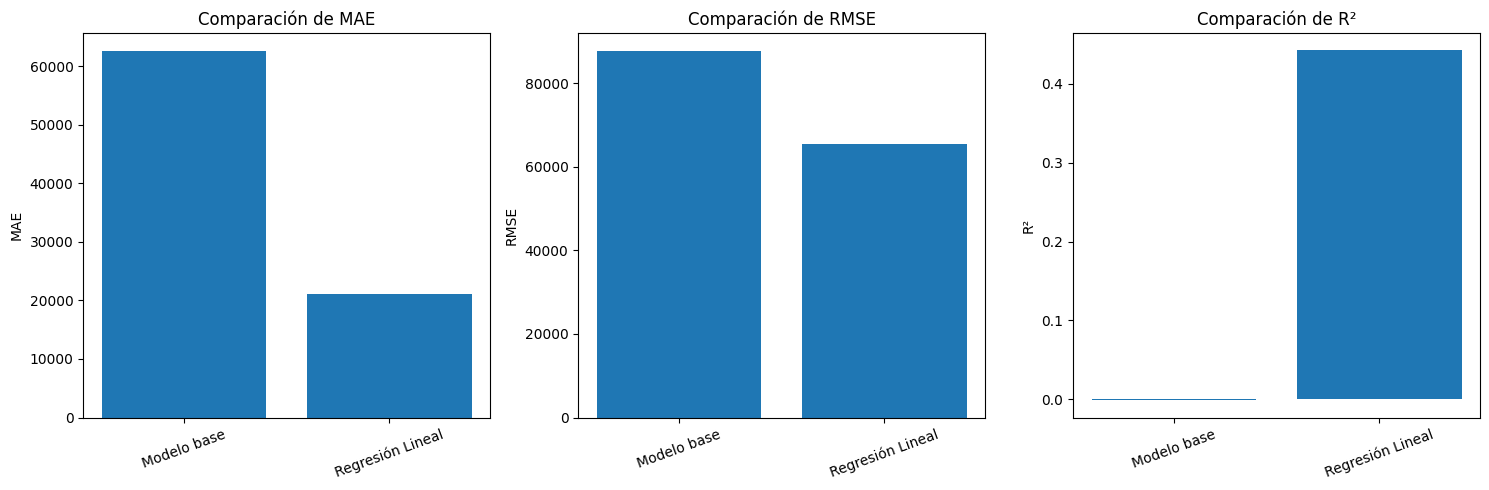

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE
axes[0].bar(["Modelo base", "Regresión Lineal"],
            [mae_base, mae_modelo])
axes[0].set_title("Comparación de MAE")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=20)

# RMSE
axes[1].bar(["Modelo base", "Regresión Lineal"],
            [rmse_base, rmse_modelo])
axes[1].set_title("Comparación de RMSE")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=20)

# R²
axes[2].bar(["Modelo base", "Regresión Lineal"],
            [r2_base, r2_modelo])
axes[2].set_title("Comparación de R²")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## **Interpretación de los resultados**

La comparación entre el modelo base y el modelo predictivo permite evaluar si la **Regresión Lineal** logra mejorar las predicciones de `SalePrice` frente a una estrategia de referencia que utiliza únicamente el valor promedio del conjunto de entrenamiento.

Los resultados muestran una mejora en las tres métricas evaluadas. En primer lugar, el **MAE** disminuye considerablemente respecto al modelo base, pasando de aproximadamente **62.600** a **21.000**. Esto indica que, en promedio, las predicciones de la Regresión Lineal presentan un error absoluto mucho menor.

De manera similar, el **RMSE** se reduce de aproximadamente **87.000** en el modelo base a **65.500** en la Regresión Lineal. Esta reducción indica una mejora en el desempeño predictivo y muestra que el modelo logra disminuir el impacto de los errores de mayor magnitud.

Finalmente, el **R²** del modelo base se encuentra cercano a **0**, lo cual es esperable debido a que este modelo utiliza únicamente el promedio de `SalePrice` como predicción. En cambio, la Regresión Lineal obtiene un **R² cercano a 0,44**, indicando que el modelo logra explicar aproximadamente el **44 % de la variabilidad observada en los precios de venta** a partir de las variables utilizadas.



#### **Conclusión de la comparación**

En conjunto, los resultados muestran que la **Regresión Lineal presenta un mejor desempeño que el modelo base**, ya que obtiene valores menores de MAE y RMSE y un valor mayor de R². Esto evidencia que las variables predictoras incorporadas al modelo aportan información útil para estimar `SalePrice`.

Sin embargo, el valor de R² obtenido indica que todavía existe una proporción importante de la variabilidad del precio que no es explicada por el modelo. Por lo tanto, aunque la Regresión Lineal representa una mejora clara frente al modelo base, **existe margen para explorar modelos predictivos más complejos y otras estrategias de modelado**.

Por tanto, la evaluación realizada permite validar que el modelo predictivo **supera al modelo base** y que las métricas seleccionadas permiten cuantificar esta mejora de manera objetiva. La comparación se realizó sobre el mismo conjunto de prueba, garantizando que ambos modelos fueran evaluados bajo las mismas condiciones.

## **Validación del modelo**

Para validar el modelo se dividió el conjunto de datos en dos subconjuntos mediante la función `train_test_split` de Scikit-learn. Se utilizó un **80 % de los datos para entrenamiento y un 20 % para prueba**, utilizando `random_state=42` para garantizar que la división sea reproducible.

La estrategia 80/20 permite disponer de una cantidad suficiente de datos para que el modelo aprenda los patrones presentes en las variables predictoras, manteniendo al mismo tiempo un conjunto independiente para evaluar su capacidad de generalización sobre datos que no fueron utilizados durante el entrenamiento.

La división utilizada fue:

- **80 % para entrenamiento:** 1168 observaciones.
- **20 % para prueba:** 292 observaciones.
- **`random_state=42`:** permite obtener la misma división cada vez que se ejecuta el notebook.

La evaluación se realizó sobre el conjunto de prueba utilizando las métricas **MAE, RMSE y R²**. Los resultados obtenidos fueron:

- **Modelo base:** MAE ≈ 62.600, RMSE ≈ 87.000 y R² ≈ 0.
- **Regresión Lineal:** MAE ≈ 21.000, RMSE ≈ 65.500 y R² ≈ 0,44.

Los resultados muestran que la Regresión Lineal presenta menores valores de MAE y RMSE y un mayor valor de R² respecto al modelo base. Por lo tanto, el modelo predictivo logra un mejor desempeño sobre el conjunto de prueba que la estrategia de referencia.

## **Reproducibilidad**

Con el fin de garantizar la reproducibilidad de los resultados, el notebook fue estructurado para que pueda ejecutarse de manera secuencial desde el inicio hasta el final, sin requerir intervención manual.

Para la división de los datos se utilizó `random_state=42`, lo que permite obtener siempre la misma partición entre los conjuntos de entrenamiento y prueba al volver a ejecutar el notebook.

La estructura del notebook sigue un orden lógico: carga y exploración de los datos, preparación y limpieza, definición de variables predictoras y variable objetivo, división de los datos, construcción del preprocesamiento, entrenamiento de los modelos, evaluación y comparación de resultados.

Además, se mantienen únicamente las celdas necesarias para el desarrollo y evaluación del modelo, evitando código de prueba o ejecuciones que no sean necesarias para reproducir los resultados.

Las principales librerías utilizadas se encuentran documentadas en el notebook, entre ellas `pandas`, `numpy`, `scikit-learn` y `matplotlib`.

De esta manera, el procedimiento completo puede ser reproducido ejecutando las celdas en el orden establecido.

<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>

## **Almacenamiento del modelo**

Una vez finalizado el entrenamiento y evaluación del modelo predictivo, se procede a almacenarlo en disco para permitir su reutilización en las siguientes fases del proyecto.

Se utilizará la biblioteca `joblib`, adecuada para almacenar modelos de Scikit-learn junto con los objetos asociados al proceso de entrenamiento.

En este caso se almacenará el pipeline completo `modelo_predictivo`, que contiene tanto el preprocesamiento de los datos como el modelo de Regresión Lineal. De esta manera, al cargar posteriormente el archivo, se conserva el flujo completo necesario para generar nuevas predicciones.

In [99]:
import joblib

ruta_modelo = "modelo.joblib"

joblib.dump(modelo_predictivo, ruta_modelo)

print(f"Modelo guardado correctamente en: {ruta_modelo}")

Modelo guardado correctamente en: modelo.joblib


In [100]:
modelo_cargado = joblib.load(ruta_modelo)

print("Modelo cargado correctamente.")
print(modelo_cargado)

Modelo cargado correctamente.
Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalamiento',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                         

In [101]:
predicciones_guardado = modelo_cargado.predict(X_test)

print("Predicciones generadas correctamente.")
print("Primeras 5 predicciones:")
print(predicciones_guardado[:5])

Predicciones generadas correctamente.
Primeras 5 predicciones:
[160141.22104349 342824.88320246  90140.87261952 176422.17406552
 321478.05706719]


## **Verificación del almacenamiento y reutilización**

La prueba realizada demuestra que el modelo predictivo puede ser almacenado correctamente en disco mediante `joblib` y posteriormente cargado sin necesidad de volver a entrenarlo.

Después de cargar el archivo `modelo.joblib`, el modelo fue utilizado para generar predicciones sobre el conjunto de prueba. Esto confirma que el modelo almacenado conserva tanto el preprocesamiento como el algoritmo de Regresión Lineal y puede ser reutilizado para realizar nuevas predicciones en fases posteriores del proyecto.

<img src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"><br><br>

<div>
  <img style="width:100%" src="https://capsule-render.vercel.app/api?type=waving&height=100&section=footer&fontSize=70&fontColor=FFFFFF&color=87CEEB" />
</div>
